# Setup D: inclined pipe effective sample size proxy

## 1. Title and purpose

This notebook develops a first-order engineering model for **Setup D**, an inclined powder pipe with an NIR diffuse reflectance probe mounted in the lower part of the pipe. The objective is to estimate a **flow-based effective sample size proxy** during one spectrum acquisition.

The result is best interpreted as a **gross refreshed optical mass / effective sample size proxy**. It is not a full radiative-transfer model, not a particulate sampling-theory model, and not a validated estimate of independent sample mass.

## 2. Scientific background

### NIR diffuse reflectance analysis of powders

In diffuse reflectance NIR measurements, light enters a powder bed, interacts with particles over a limited depth, and a fraction of the scattered light returns to the detector. The measured spectrum therefore reflects an **optically weighted near-surface volume** rather than the entire bulk stream.

### Why use a simple optical interaction approximation?

For engineering comparisons, it is often useful to approximate the optical interaction region with a simple geometric volume. Here, the optical sampling region is approximated as a cylinder with:

- cross-sectional area equal to the probe window footprint
- depth equal to an assumed light penetration depth

This simplification ignores depth-dependent photon weighting, scattering anisotropy, particle packing effects, and spectral absorption details, but it provides a practical way to compare conditions.

### Why moving powder increases the sampled mass during one acquisition

If powder continuously moves past the probe during one acquisition, the optical interaction zone is refreshed. Faster renewal means that more powder volume can pass through the probe footprint during the acquisition period. That does not guarantee statistical independence of all material seen by the instrument, but it increases the gross refreshed optical mass available to contribute to the measurement.

### Why Setup D differs from other geometries

Setup D differs from a **static powder bed** because the material in front of the probe is continuously replaced. It also differs from a **mechanically refreshed geometry such as the spiderwheel** because the refresh mechanism is not imposed by discrete compartments or controlled mechanical presentation. Instead, it is driven by gravity-assisted powder transport through a tilted pipe.

### Why a superficial velocity model is useful

A practical first approximation is to connect throughput, bulk density, and pipe cross-sectional area to a **superficial bulk velocity**. This gives a simple estimate of how quickly powder is renewed in front of the probe. In reality, the local flow at the lower wall of a tilted pipe may differ substantially from the cross-sectional average, but the superficial velocity remains a useful baseline for sensitivity analysis and engineering intuition.

## 3. Setup D device description

Setup D is modeled as follows:

- pipe internal diameter = **100 mm**
- pipe axis tilted **15 degrees from vertical**
- powder enters from above and moves downward toward the outlet
- due to the tilt, powder is expected to slide preferentially along the **lower side of the pipe**
- the NIR probe is mounted in the **lower part of the pipe**
- the probe window is assumed to be **continuously covered by powder**
- the effective sample size proxy therefore depends primarily on **powder renewal in front of the probe**

This notebook uses a **first-order flow approximation**. The 15 degree tilt is included as part of the physical setup description and qualitative interpretation, but the base model still estimates renewal from the total throughput, bulk density, and full pipe cross-sectional area.

## 4. Model assumptions

The base model uses the following assumptions:

- the optical sampling volume is approximated as a cylinder: **probe window area x penetration depth**
- the probe window is fully covered by powder at all times
- powder renewal at the probe is approximated by a **bulk superficial velocity** derived from throughput, density, and pipe cross-sectional area
- bulk density is constant and spatially uniform
- no explicit blocking events occur
- no recirculation correction is included
- local wall velocity may differ from average superficial velocity, but that difference is ignored in the base model
- the output is a **flow-based effective sample size proxy**, not a validated independent sample mass

These assumptions intentionally favor transparency and reuse over physical completeness.

## 5. Mathematical model

Internal units used throughout the notebook are:

- geometry in **cm**
- time in **s**
- density in **g/cm$^3$**
- throughput entered in **kg/h** and converted internally to **g/s**
- penetration depth entered in **mm** and converted internally to **cm**
- final reported effective sample size proxy in **mg**

Pipe radius:

$$
r_{\mathrm{pipe}} = \frac{d_{\mathrm{pipe}}}{2}
$$

Pipe cross-sectional area:

$$
A_{\mathrm{pipe}} = \pi r_{\mathrm{pipe}}^2
$$

Mass flow conversion:

$$
\dot{m}_{\mathrm{g/s}} = \dot{m}_{\mathrm{kg/h}} \cdot \frac{1000}{3600}
$$

Superficial velocity:

$$
v = \frac{\dot{m}}{\rho A_{\mathrm{pipe}}}
$$

Probe footprint area:

$$
A_{\mathrm{probe}} = \pi \left(\frac{d_{\mathrm{probe}}}{2}\right)^2
$$

Optical volume per static slice:

$$
V_{\mathrm{opt}} = A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

Optical mass per static slice:

$$
m_{\mathrm{opt}} = \rho \cdot V_{\mathrm{opt}}
$$

Crossing time of one probe diameter:

$$
t_{\mathrm{cross}} = \frac{d_{\mathrm{probe}}}{v}
$$

Number of refreshes during acquisition:

$$
N_{\mathrm{refresh}} = \frac{t_{\mathrm{acq}}}{t_{\mathrm{cross}}}
$$

Effective sample size proxy:

$$
m_{\mathrm{eff,proxy}} = m_{\mathrm{opt}} \cdot N_{\mathrm{refresh}}
$$

Equivalent transported-volume view:

$$
V_{\mathrm{passed}} = v \cdot A_{\mathrm{probe}} \cdot t_{\mathrm{acq}}
$$

$$
m_{\mathrm{passed}} = \rho \cdot V_{\mathrm{passed}}
$$

Under the simplified assumptions, these forms are equivalent because the probe footprint is refreshed by translation of material past the window. The 15 degree tilt remains part of the physical setup description, but the base model still uses the cross-sectional superficial velocity as the first-order renewal velocity approximation.

In [1]:
# 6. Imports
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:
# 7. User-defined parameters

pipe_diameter_mm = 100.0  # Pipe internal diameter [mm]
pipe_tilt_deg_from_vertical = 15.0  # Pipe axis tilt from vertical [deg]
probe_diameter_mm = 5.0  # NIR probe window diameter [mm]
acquisition_time_s = 1.0  # Spectrum acquisition time [s]

throughput_values_kg_h = list(range(40, 101, 5))  # Throughput sweep [kg/h]
density_values_g_cm3 = [0.4, 0.5, 0.6]  # Bulk density scenarios [g/cm^3]
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)  # Penetration depth sweep [mm]

worked_example_throughput_kg_h = 70.0  # Worked example throughput [kg/h]
worked_example_density_g_cm3 = 0.5  # Worked example bulk density [g/cm^3]
worked_example_penetration_depth_mm = 1.0  # Worked example penetration depth [mm]


In [3]:
# 8. Helper functions

def _validate_positive(value, name):
    """Raise a ValueError if value is not strictly positive."""
    if value <= 0:
        raise ValueError(f'{name} must be positive; received {value!r}.')


def mm_to_cm(mm):
    """Convert millimeters to centimeters."""
    _validate_positive(mm, 'mm')
    return mm / 10.0


def kg_h_to_g_s(kg_h):
    """Convert mass flow from kilograms per hour to grams per second."""
    _validate_positive(kg_h, 'kg_h')
    return kg_h * 1000.0 / 3600.0


def pipe_cross_section_area_cm2(pipe_diameter_cm):
    """Return pipe cross-sectional area in cm^2."""
    _validate_positive(pipe_diameter_cm, 'pipe_diameter_cm')
    radius_cm = pipe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def probe_area_cm2(probe_diameter_cm):
    """Return probe footprint area in cm^2."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    radius_cm = probe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm):
    """Estimate superficial bulk velocity in the pipe in cm/s."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    throughput_g_s = kg_h_to_g_s(throughput_kg_h)
    area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
    return throughput_g_s / (density_g_cm3 * area_cm2)


def optical_volume_cm3(probe_diameter_cm, penetration_depth_cm):
    """Return static optical interaction volume in cm^3."""
    _validate_positive(penetration_depth_cm, 'penetration_depth_cm')
    return probe_area_cm2(probe_diameter_cm) * penetration_depth_cm


def optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Return static optical mass in grams."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    return density_g_cm3 * optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)


def crossing_time_s(probe_diameter_cm, velocity_cm_s):
    """Return time for material to move one probe diameter in seconds."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return probe_diameter_cm / velocity_cm_s


def passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return powder volume passing the probe footprint during one acquisition in cm^3."""
    _validate_positive(acquisition_time_s, 'acquisition_time_s')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return velocity_cm_s * probe_area_cm2(probe_diameter_cm) * acquisition_time_s


def passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return powder mass passing the probe footprint during one acquisition in mg."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    volume_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
    return density_g_cm3 * volume_cm3 * 1000.0


def effective_sample_mass_proxy_mg(
    throughput_kg_h,
    density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
):
    """Return a dictionary of first-order flow-based effective sample proxy quantities."""
    velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
    optical_mass_per_refresh_g = optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm)
    t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
    n_refresh = acquisition_time_s / t_cross_s
    effective_mass_proxy_mg = optical_mass_per_refresh_g * n_refresh * 1000.0

    return {
        'superficial_velocity_cm_s': velocity_cm_s,
        'optical_mass_per_refresh_g': optical_mass_per_refresh_g,
        'crossing_time_s': t_cross_s,
        'n_refresh': n_refresh,
        'effective_sample_mass_proxy_mg': effective_mass_proxy_mg,
    }


## 9. Single-case worked example

The worked example uses:

- throughput = **70 kg/h**
- density = **0.5 g/cm$^3$**
- pipe diameter = **100 mm**
- pipe tilt = **15 degrees from vertical**
- probe diameter = **5.0 mm**
- penetration depth = **1.0 mm**
- acquisition time = **1.0 s**

This example should be interpreted as a **first-order estimate**. In a real tilted pipe, the local velocity at the lower wall may differ from the superficial velocity because the flowing layer can be asymmetric and concentrated near the lower side.

In [4]:
pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
penetration_depth_cm = mm_to_cm(worked_example_penetration_depth_mm)

pipe_area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
throughput_g_s = kg_h_to_g_s(worked_example_throughput_kg_h)
velocity_cm_s = superficial_velocity_cm_s(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
)
probe_area_value_cm2 = probe_area_cm2(probe_diameter_cm)
optical_volume_value_cm3 = optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)
optical_mass_value_g = optical_mass_g(
    worked_example_density_g_cm3,
    probe_diameter_cm,
    penetration_depth_cm,
)
crossing_time_value_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
n_refresh_value = acquisition_time_s / crossing_time_value_s
effective_proxy = effective_sample_mass_proxy_mg(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
)
passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
passed_mass_value_mg = passed_mass_mg(
    worked_example_density_g_cm3,
    velocity_cm_s,
    probe_diameter_cm,
    acquisition_time_s,
)

print('Worked example: Setup D first-order estimate')
print(f'Pipe tilt from vertical: {pipe_tilt_deg_from_vertical:.1f} deg')
print(f'Pipe cross-sectional area: {pipe_area_cm2:.4f} cm^2')
print(f'Throughput: {throughput_g_s:.4f} g/s')
print(f'Superficial velocity: {velocity_cm_s:.4f} cm/s')
print(f'Probe area: {probe_area_value_cm2:.6f} cm^2')
print(f'Optical volume per static slice: {optical_volume_value_cm3:.6f} cm^3')
print(f'Optical mass per static slice: {optical_mass_value_g * 1000.0:.4f} mg')
print(f'Crossing time: {crossing_time_value_s:.4f} s')
print(f'Number of refreshes during acquisition: {n_refresh_value:.4f}')
print(f"Effective sample size proxy: {effective_proxy['effective_sample_mass_proxy_mg']:.4f} mg")
print(f'Passed volume during acquisition: {passed_volume_value_cm3:.6f} cm^3')
print(f'Passed mass during acquisition: {passed_mass_value_mg:.4f} mg')


Worked example: Setup D first-order estimate
Pipe tilt from vertical: 15.0 deg
Pipe cross-sectional area: 78.5398 cm^2
Throughput: 19.4444 g/s
Superficial velocity: 0.4951 cm/s
Probe area: 0.196350 cm^2
Optical volume per static slice: 0.019635 cm^3
Optical mass per static slice: 9.8175 mg
Crossing time: 1.0098 s
Number of refreshes during acquisition: 0.9903
Effective sample size proxy: 9.7222 mg
Passed volume during acquisition: 0.097222 cm^3
Passed mass during acquisition: 48.6111 mg


## 10. Parameter sweep across throughput, density, and penetration depth

The full sweep spans:

- throughput from **40 to 100 kg/h**
- density = **0.4, 0.5, 0.6 g/cm$^3$**
- penetration depth from **0.1 to 2.0 mm** in 0.1 mm steps
- probe diameter fixed at **5 mm**
- acquisition time fixed at **1.0 s** unless changed in the parameter cell

In [5]:
records = []

pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
pipe_area_cm2_value = pipe_cross_section_area_cm2(pipe_diameter_cm)

for throughput_kg_h in throughput_values_kg_h:
    throughput_g_s = kg_h_to_g_s(throughput_kg_h)
    for density_g_cm3 in density_values_g_cm3:
        velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
        t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
        n_refresh = acquisition_time_s / t_cross_s
        passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
        passed_mass_value_mg = passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s)

        for penetration_depth_mm in penetration_depth_values_mm:
            penetration_depth_cm = mm_to_cm(float(penetration_depth_mm))
            proxy = effective_sample_mass_proxy_mg(
                throughput_kg_h,
                density_g_cm3,
                pipe_diameter_cm,
                probe_diameter_cm,
                penetration_depth_cm,
                acquisition_time_s,
            )
            optical_mass_per_refresh_mg = (
                optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm) * 1000.0
            )

            records.append(
                {
                    'throughput_kg_h': throughput_kg_h,
                    'density_g_cm3': density_g_cm3,
                    'pipe_diameter_mm': pipe_diameter_mm,
                    'pipe_tilt_deg_from_vertical': pipe_tilt_deg_from_vertical,
                    'penetration_depth_mm': float(penetration_depth_mm),
                    'probe_diameter_mm': probe_diameter_mm,
                    'acquisition_time_s': acquisition_time_s,
                    'throughput_g_s': throughput_g_s,
                    'pipe_area_cm2': pipe_area_cm2_value,
                    'superficial_velocity_cm_s': velocity_cm_s,
                    'optical_mass_per_refresh_mg': optical_mass_per_refresh_mg,
                    'crossing_time_s': t_cross_s,
                    'n_refresh': n_refresh,
                    'effective_sample_mass_proxy_mg': proxy['effective_sample_mass_proxy_mg'],
                    'passed_volume_cm3': passed_volume_value_cm3,
                    'passed_mass_mg': passed_mass_value_mg,
                }
            )

results_df = pd.DataFrame(records)
results_df = results_df.sort_values(
    ['density_g_cm3', 'throughput_kg_h', 'penetration_depth_mm'], ignore_index=True
)

print(f'Generated {len(results_df)} modeled scenarios.')


Generated 780 modeled scenarios.


## 11. Results tables

In [6]:
results_df.head(12)


,throughput_kg_h,density_g_cm3,pipe_diameter_mm,pipe_tilt_deg_from_vertical,penetration_depth_mm,probe_diameter_mm,acquisition_time_s,throughput_g_s,pipe_area_cm2,superficial_velocity_cm_s,optical_mass_per_refresh_mg,crossing_time_s,n_refresh,effective_sample_mass_proxy_mg,passed_volume_cm3,passed_mass_mg
0,40,0.4000,100.0000,15.0000,0.1000,5.0000,1.0000,11.1111,78.5398,0.3537,0.7854,1.4137,0.7074,0.5556,0.0694,27.7778
1,40,0.4000,100.0000,15.0000,0.2000,5.0000,1.0000,11.1111,78.5398,0.3537,1.5708,1.4137,0.7074,1.1111,0.0694,27.7778
2,40,0.4000,100.0000,15.0000,0.3000,5.0000,1.0000,11.1111,78.5398,0.3537,2.3562,1.4137,0.7074,1.6667,0.0694,27.7778
3,40,0.4000,100.0000,15.0000,0.4000,5.0000,1.0000,11.1111,78.5398,0.3537,3.1416,1.4137,0.7074,2.2222,0.0694,27.7778
4,40,0.4000,100.0000,15.0000,0.5000,5.0000,1.0000,11.1111,78.5398,0.3537,3.9270,1.4137,0.7074,2.7778,0.0694,27.7778
5,40,0.4000,100.0000,15.0000,0.6000,5.0000,1.0000,11.1111,78.5398,0.3537,4.7124,1.4137,0.7074,3.3333,0.0694,27.7778
6,40,0.4000,100.0000,15.0000,0.7000,5.0000,1.0000,11.1111,78.5398,0.3537,5.4978,1.4137,0.7074,3.8889,0.0694,27.7778
7,40,0.4000,100.0000,15.0000,0.8000,5.0000,1.0000,11.1111,78.5398,0.3537,6.2832,1.4137,0.7074,4.4444,0.0694,27.7778
8,40,0.4000,100.0000,15.0000,0.9000,5.0000,1.0000,11.1111,78.5398,0.3537,7.0686,1.4137,0.7074,5.0000,0.0694,27.7778
9,40,0.4000,100.0000,15.0000,1.0000,5.0000,1.0000,11.1111,78.5398,0.3537,7.8540,1.4137,0.7074,5.5556,0.0694,27.7778


In [7]:
selected_scenarios = results_df[
    results_df['throughput_kg_h'].isin([40, 70, 100])
    & results_df['density_g_cm3'].isin([0.4, 0.5, 0.6])
    & results_df['penetration_depth_mm'].isin([0.5, 1.0, 2.0])
].copy()

selected_scenarios[
    [
        'throughput_kg_h',
        'density_g_cm3',
        'penetration_depth_mm',
        'superficial_velocity_cm_s',
        'optical_mass_per_refresh_mg',
        'n_refresh',
        'effective_sample_mass_proxy_mg',
        'passed_mass_mg',
    ]
].reset_index(drop=True)


,throughput_kg_h,density_g_cm3,penetration_depth_mm,superficial_velocity_cm_s,optical_mass_per_refresh_mg,n_refresh,effective_sample_mass_proxy_mg,passed_mass_mg
0,40,0.4000,0.5000,0.3537,3.9270,0.7074,2.7778,27.7778
1,40,0.4000,1.0000,0.3537,7.8540,0.7074,5.5556,27.7778
2,40,0.4000,2.0000,0.3537,15.7080,0.7074,11.1111,27.7778
3,70,0.4000,0.5000,0.6189,3.9270,1.2379,4.8611,48.6111
4,70,0.4000,1.0000,0.6189,7.8540,1.2379,9.7222,48.6111
5,70,0.4000,2.0000,0.6189,15.7080,1.2379,19.4444,48.6111
6,100,0.4000,0.5000,0.8842,3.9270,1.7684,6.9444,69.4444
7,100,0.4000,1.0000,0.8842,7.8540,1.7684,13.8889,69.4444
8,100,0.4000,2.0000,0.8842,15.7080,1.7684,27.7778,69.4444
9,40,0.5000,0.5000,0.2829,4.9087,0.5659,2.7778,27.7778


In [8]:
pivot_density_05 = results_df[results_df['density_g_cm3'] == 0.5].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_proxy_mg',
)

pivot_density_06 = results_df[results_df['density_g_cm3'] == 0.6].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_proxy_mg',
)

pivot_density_05.iloc[:8, :6]


throughput_kg_h,40,45,50,55,60,65
penetration_depth_mm,,,,,,
0.1000,0.5556,0.6250,0.6944,0.7639,0.8333,0.9028
0.2000,1.1111,1.2500,1.3889,1.5278,1.6667,1.8056
0.3000,1.6667,1.8750,2.0833,2.2917,2.5000,2.7083
0.4000,2.2222,2.5000,2.7778,3.0556,3.3333,3.6111
0.5000,2.7778,3.1250,3.4722,3.8194,4.1667,4.5139
0.6000,3.3333,3.7500,4.1667,4.5833,5.0000,5.4167
0.7000,3.8889,4.3750,4.8611,5.3472,5.8333,6.3194
0.8000,4.4444,5.0000,5.5556,6.1111,6.6667,7.2222


## 12. Visualization

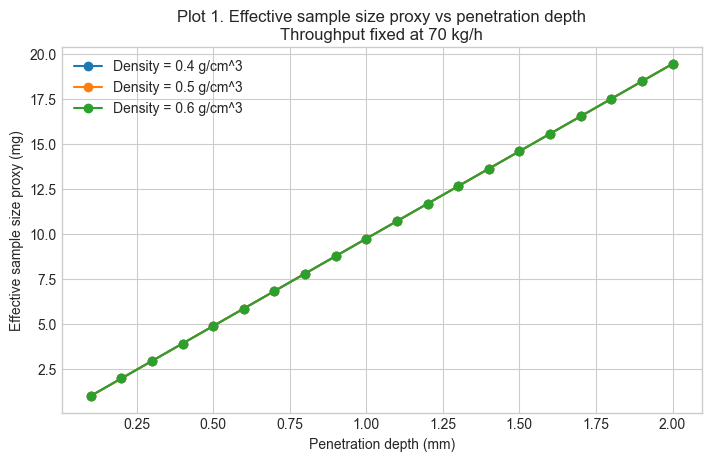

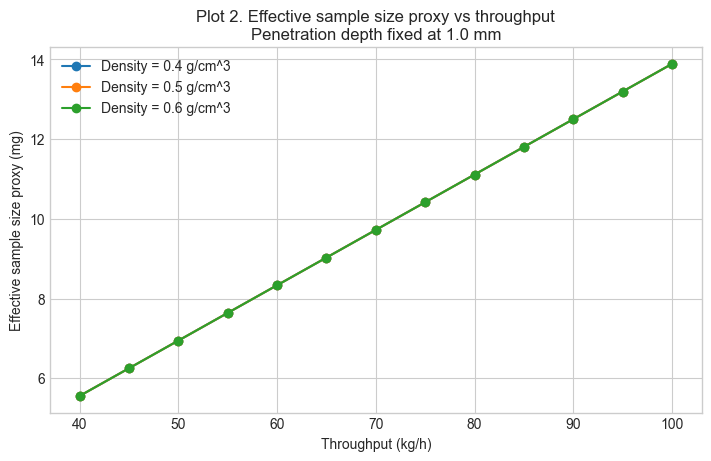

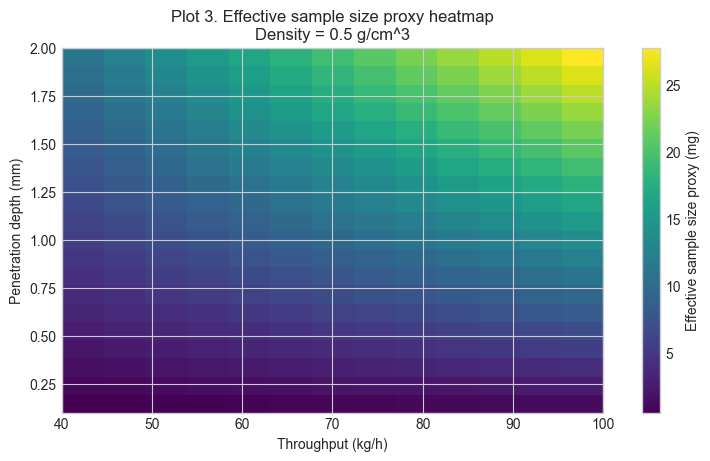

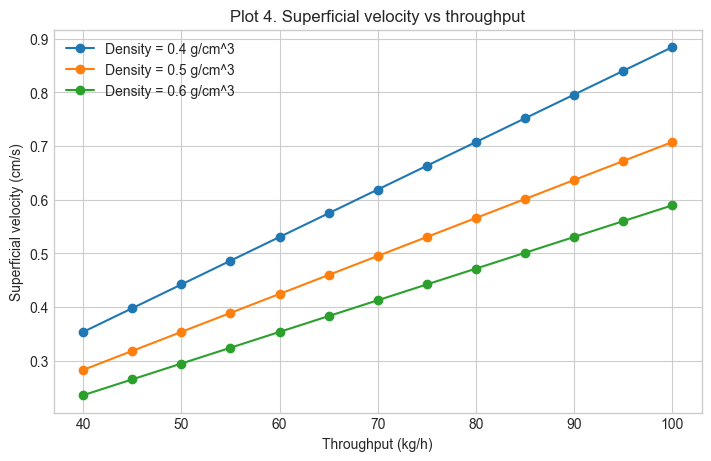

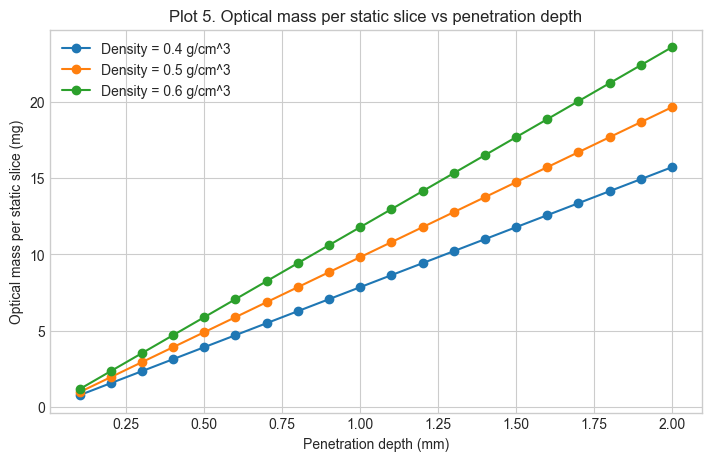

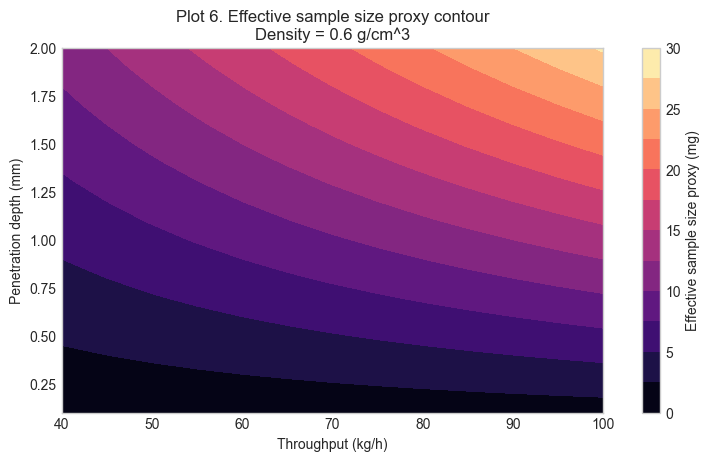

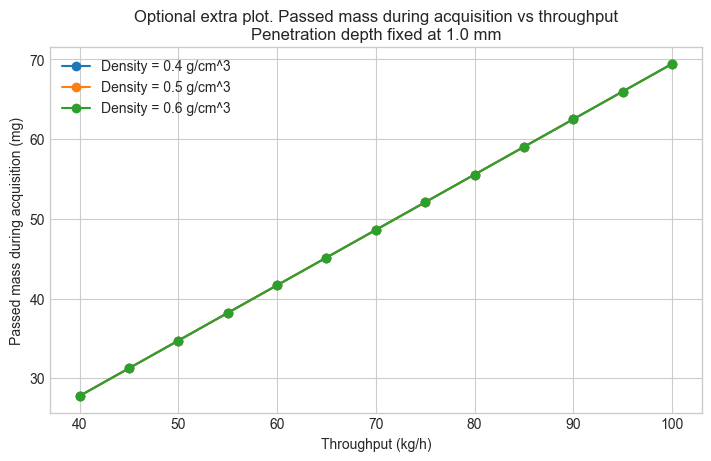

In [9]:
# Plot 1: effective proxy vs penetration depth at fixed throughput
fig_setup_d_plot_01, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot1_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['effective_sample_mass_proxy_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 1. Effective sample size proxy vs penetration depth\nThroughput fixed at 70 kg/h')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.legend()
plt.show()

# Plot 2: effective proxy vs throughput at fixed penetration depth
fig_setup_d_plot_02, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot2_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = plot2_df[plot2_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['effective_sample_mass_proxy_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 2. Effective sample size proxy vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Effective sample size proxy (mg)')
ax.legend()
plt.show()

# Plot 3: heatmap for density 0.5 g/cm^3
fig_setup_d_plot_03, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
im = ax.imshow(
    pivot_density_05.values,
    aspect='auto',
    origin='lower',
    extent=[
        pivot_density_05.columns.min(),
        pivot_density_05.columns.max(),
        pivot_density_05.index.min(),
        pivot_density_05.index.max(),
    ],
    cmap='viridis',
)
ax.set_title('Plot 3. Effective sample size proxy heatmap\nDensity = 0.5 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_03.colorbar(im, ax=ax, label='Effective sample size proxy (mg)')
plt.show()

# Plot 4: superficial velocity vs throughput
fig_setup_d_plot_04, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
velocity_plot_df = (
    results_df[['throughput_kg_h', 'density_g_cm3', 'superficial_velocity_cm_s']]
    .drop_duplicates()
    .sort_values(['density_g_cm3', 'throughput_kg_h'])
)
for density in density_values_g_cm3:
    subset = velocity_plot_df[velocity_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['superficial_velocity_cm_s'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 4. Superficial velocity vs throughput')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Superficial velocity (cm/s)')
ax.legend()
plt.show()

# Plot 5: optical mass per static slice vs penetration depth
fig_setup_d_plot_05, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot5_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot5_df[plot5_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['optical_mass_per_refresh_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 5. Optical mass per static slice vs penetration depth')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Optical mass per static slice (mg)')
ax.legend()
plt.show()

# Plot 6: contour plot for density 0.6 g/cm^3
fig_setup_d_plot_06, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
T, P = np.meshgrid(pivot_density_06.columns.to_numpy(), pivot_density_06.index.to_numpy())
contour = ax.contourf(T, P, pivot_density_06.values, levels=12, cmap='magma')
ax.set_title('Plot 6. Effective sample size proxy contour\nDensity = 0.6 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_06.colorbar(contour, ax=ax, label='Effective sample size proxy (mg)')
plt.show()

fig_setup_d_passed_mass, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
extra_plot_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = extra_plot_df[extra_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['passed_mass_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Optional extra plot. Passed mass during acquisition vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Passed mass during acquisition (mg)')
ax.legend()
plt.show()


## 13. Interpretation of trends

Several clear trends appear in this first-order model.

- Increasing **density** increases the **optical mass per static slice** linearly because $m_{\mathrm{opt}} = \rho A_{\mathrm{probe}} d_{\mathrm{pen}}$.
- Increasing **penetration depth** increases the **optical mass per static slice** linearly because the modeled optical volume grows linearly with depth.
- Increasing **throughput** increases the **superficial velocity** linearly for fixed density and pipe area.
- Increasing superficial velocity decreases the **crossing time** and therefore increases the **refresh count** during one acquisition.
- The result should be interpreted as a **flow-based refreshed optical mass proxy**, not necessarily an independent sampling mass.

### Density cancellation under the simplified assumptions

Starting from:

$$
m_{\mathrm{eff,proxy}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}} \cdot \frac{t_{\mathrm{acq}}}{d_{\mathrm{probe}}/v}
$$

and substituting:

$$
v = \frac{\dot{m}}{\rho A_{\mathrm{pipe}}}
$$

gives:

$$
m_{\mathrm{eff,proxy}} = \rho A_{\mathrm{probe}} d_{\mathrm{pen}} t_{\mathrm{acq}} \cdot \frac{v}{d_{\mathrm{probe}}}
$$

$$
m_{\mathrm{eff,proxy}} = \rho A_{\mathrm{probe}} d_{\mathrm{pen}} t_{\mathrm{acq}} \cdot \frac{1}{d_{\mathrm{probe}}} \cdot \frac{\dot{m}}{\rho A_{\mathrm{pipe}}}
$$

$$
m_{\mathrm{eff,proxy}} = \frac{A_{\mathrm{probe}} d_{\mathrm{pen}} t_{\mathrm{acq}}}{d_{\mathrm{probe}} A_{\mathrm{pipe}}} \cdot \dot{m}
$$

So, in this specific simplified model, **density cancels completely** for the effective sample size proxy when throughput is fixed in mass units and the whole pipe cross-section is assumed to participate in the superficial flow. Physically, a higher density increases the static optical mass seen at one instant, but it simultaneously reduces the superficial velocity in the same proportion. The larger mass per refresh and the smaller number of refreshes offset each other.

This complete cancellation is a direct consequence of the model structure. In a more realistic tilted-pipe model, density could re-enter through changes in flowing layer thickness, local wall velocity, consolidation, slip, or coverage dynamics.

## 14. Model limitations

Important limitations of this notebook are:

- the cylindrical optical volume is only an approximation
- there is no radiative-transfer model and no photon weighting with depth
- superficial velocity may differ from the true local wall velocity at the probe location
- the 15 degree tilt is represented only qualitatively in the base model
- there is no correction for asymmetric sliding-layer thickness
- there is no correction for stagnant regions or wall slip
- there is no particle size or particle count model
- there is no recirculation correction
- the model is not linked directly to analytical variance or Gy sampling theory

Useful future refinements could include:

- an effective moving-layer thickness
- a local wall velocity factor
- a filling fraction or flowing cross-sectional area correction
- a residence-time or particle revisit model

## 15. Conclusions

This notebook estimates a **first-order flow-based effective sample size proxy** for Setup D, expressed as refreshed optical mass during one spectrum acquisition.

Within this model, the strongest explicit drivers are:

- **throughput**, which sets superficial velocity and refresh rate
- **penetration depth**, which scales the optical mass per refresh
- **probe and pipe geometry**, which determine the footprint and renewal scale

The notebook is useful for **sensitivity analysis**, quick scenario comparison, and engineering intuition during development. A more advanced model could incorporate local lower-wall flow kinematics, effective moving-layer thickness, nonuniform filling, revisit behavior, and optical depth weighting.

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [10]:

from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
try:
    project_root = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_d"
notebook_filename = "setup_D_pipe_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_d_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = selected_scenarios.copy()
velocity_summary_df = (
    results_df[["throughput_kg_h", "density_g_cm3", "superficial_velocity_cm_s", "passed_mass_mg"]]
    .drop_duplicates()
    .sort_values(["density_g_cm3", "throughput_kg_h"])
    .reset_index(drop=True)
)

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "velocity_summary": velocity_summary_df,
}
figures_to_save = {
    "plot_01_proxy_vs_penetration_depth": globals().get("fig_setup_d_plot_01"),
    "plot_02_proxy_vs_throughput": globals().get("fig_setup_d_plot_02"),
    "plot_03_heatmap_density_05": globals().get("fig_setup_d_plot_03"),
    "plot_04_superficial_velocity_vs_throughput": globals().get("fig_setup_d_plot_04"),
    "plot_05_optical_mass_per_refresh": globals().get("fig_setup_d_plot_05"),
    "plot_06_contour_density_06": globals().get("fig_setup_d_plot_06"),
    "plot_07_passed_mass_vs_throughput": globals().get("fig_setup_d_passed_mass"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (mm)": pipe_diameter_mm,
    "Pipe tilt from vertical (deg)": pipe_tilt_deg_from_vertical,
    "Probe diameter (mm)": probe_diameter_mm,
    "Acquisition time (s)": acquisition_time_s,
    "Throughput range (kg/h)": f"{min(throughput_values_kg_h)} to {max(throughput_values_kg_h)}",
    "Density scenarios (g/cm^3)": [float(x) for x in density_values_g_cm3],
    "Penetration depth range (mm)": f"{penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f}",
}
purpose_text = (
    "Setup D estimates a first-order flow-based effective sample size proxy in a tilted pipe by combining optical "
    "mass per refresh with a refresh rate derived from superficial velocity."
)
assumptions_text = (
    "Superficial velocity is used as a first-order flow approximation, density is uniform within each scenario, "
    "the optical volume is cylindrical, and the tilt effect is captured only through the stated simplified geometry."
)
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

build_word_report(
    report_title="Setup D Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    purpose_text=purpose_text,
    assumptions_text=assumptions_text,
    parameter_summary=parameter_summary,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    output_filename=report_filename,
)

print(f"Report run directory: {run_dir}")


Report run directory: C:\temp files\EFS\reports\setup_d\20260317_112555
